# Fase 5 — Evaluación comparativa unificada
**Proyecto:** FruitVision — Clasificación de Calidad de Frutas

---
Comparamos en **igualdad de condiciones** (mismo conjunto de prueba, split
**sin fuga**) los modelos ya entrenados:

- **Baseline** (clase mayoritaria)
- **Random Forest** (HOG + color)
- **XGBoost** (HOG + color)
- **CNN desde cero**

Este notebook **NO entrena**: carga los modelos guardados y los evalúa. Incluye
tabla comparativa, matrices de confusión, **análisis de errores** y un bloque de
**evaluación fuera de distribución (OOD)** para las imágenes propias.

In [1]:
# Bootstrap
import sys, pathlib, os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd, joblib, cv2
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
import tensorflow as tf
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

from src.config import QUALITY_CLASSES, CNN_IMG_SIZE, MODELS_DIR, FIGURES_DIR, PROCESSED_DIR
from src.data.preprocessing import load_manifest
from src.features.extract import build_feature_matrix
from src.data.paths import load_image_rgb

I0000 00:00:1780435954.844438  211750 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1780435956.107347  211750 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Cargar modelos y datos de prueba

In [2]:
# Características (ML) y etiquetas
Xtr, ytr = build_feature_matrix(load_manifest('train'), 'train')
Xte, yte = build_feature_matrix(load_manifest('test'),  'test')

# Imágenes (CNN)
def load_imgs(manifest, size=CNN_IMG_SIZE):
    X = np.zeros((len(manifest), *size, 3), np.float32)
    for i, p in enumerate(manifest['abs_path']):
        img = load_image_rgb(p)
        if img is not None:
            X[i] = cv2.resize(img, size).astype(np.float32) / 255.0
    return X
te_manifest = load_manifest('test')
Xte_img = load_imgs(te_manifest)

# Modelos
rf  = joblib.load(MODELS_DIR / "random_forest.pkl")
xgbm = joblib.load(MODELS_DIR / "xgboost.pkl")
cnn = tf.keras.models.load_model(MODELS_DIR / "cnn_quality.keras")
dummy = DummyClassifier(strategy='most_frequent').fit(Xtr, ytr)
print("Modelos cargados. Test:", Xte.shape[0], "imágenes")

E0000 00:00:1780435957.972108  211750 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


Modelos cargados. Test: 606 imágenes


## 2. Predicciones de cada modelo en el test

In [3]:
preds = {
    'Baseline':      dummy.predict(Xte),
    'Random Forest': rf.predict(Xte),
    'XGBoost':       xgbm.predict(Xte),
    'CNN':           cnn.predict(Xte_img, verbose=0).argmax(1),
}

## 3. Tabla comparativa (accuracy + F1-macro)

               accuracy  f1_macro
modelo                           
Baseline          0.365     0.178
Random Forest     0.932     0.932
XGBoost           0.937     0.937
CNN               0.957     0.956


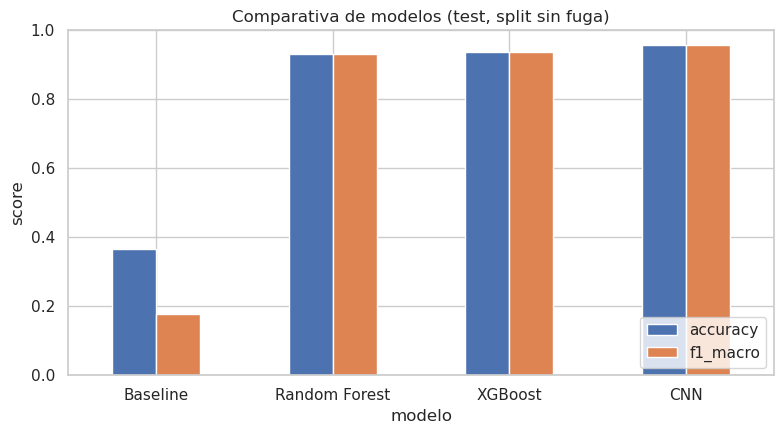

In [4]:
rows = []
for name, p in preds.items():
    rows.append({'modelo': name,
                 'accuracy': accuracy_score(yte, p),
                 'f1_macro': f1_score(yte, p, average='macro')})
results = pd.DataFrame(rows).set_index('modelo')
print(results.round(3))

ax = results.plot.bar(figsize=(8,4.5), rot=0)
ax.set_title("Comparativa de modelos (test, split sin fuga)")
ax.set_ylabel("score"); ax.set_ylim(0,1); ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig(FIGURES_DIR / "fase5_comparativa.pdf", bbox_inches="tight")
plt.show()

## 4. Métricas por clase y matrices de confusión

In [5]:
for name in ['Random Forest','XGBoost','CNN']:
    print(f"=== {name} ===")
    print(classification_report(yte, preds[name], target_names=QUALITY_CLASSES, digits=3))

=== Random Forest ===
              precision    recall  f1-score   support

     Premium      0.941     0.916     0.928       225
    Estándar      0.936     0.919     0.927       160
    Descarte      0.922     0.959     0.940       221

    accuracy                          0.932       606
   macro avg      0.933     0.931     0.932       606
weighted avg      0.933     0.932     0.932       606

=== XGBoost ===
              precision    recall  f1-score   support

     Premium      0.967     0.902     0.933       225
    Estándar      0.911     0.956     0.933       160
    Descarte      0.930     0.959     0.944       221

    accuracy                          0.937       606
   macro avg      0.936     0.939     0.937       606
weighted avg      0.938     0.937     0.937       606

=== CNN ===
              precision    recall  f1-score   support

     Premium      0.960     0.951     0.955       225
    Estándar      0.918     0.975     0.945       160
    Descarte      0.986  

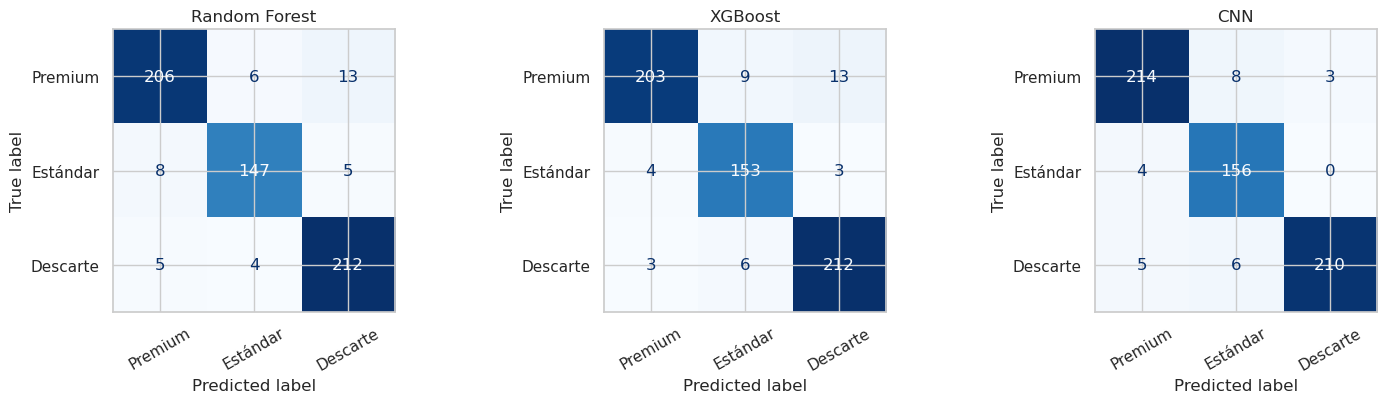

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for a, name in zip(ax, ['Random Forest','XGBoost','CNN']):
    cm = confusion_matrix(yte, preds[name])
    ConfusionMatrixDisplay(cm, display_labels=QUALITY_CLASSES).plot(ax=a, cmap='Blues', colorbar=False)
    a.set_title(name); a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "fase5_confusion.pdf", bbox_inches="tight")
plt.show()

## 5. Análisis de errores
Mostramos ejemplos mal clasificados por el mejor modelo para entender QUÉ falla
(¿fotos ambiguas? ¿confusión sistemática entre dos clases?).

Mejor modelo: CNN | errores: 26/606

Confusiones más frecuentes (real -> predicho):
  Premium   -> Estándar : 8
  Descarte  -> Estándar : 6
  Descarte  -> Premium  : 5
  Estándar  -> Premium  : 4
  Premium   -> Descarte : 3


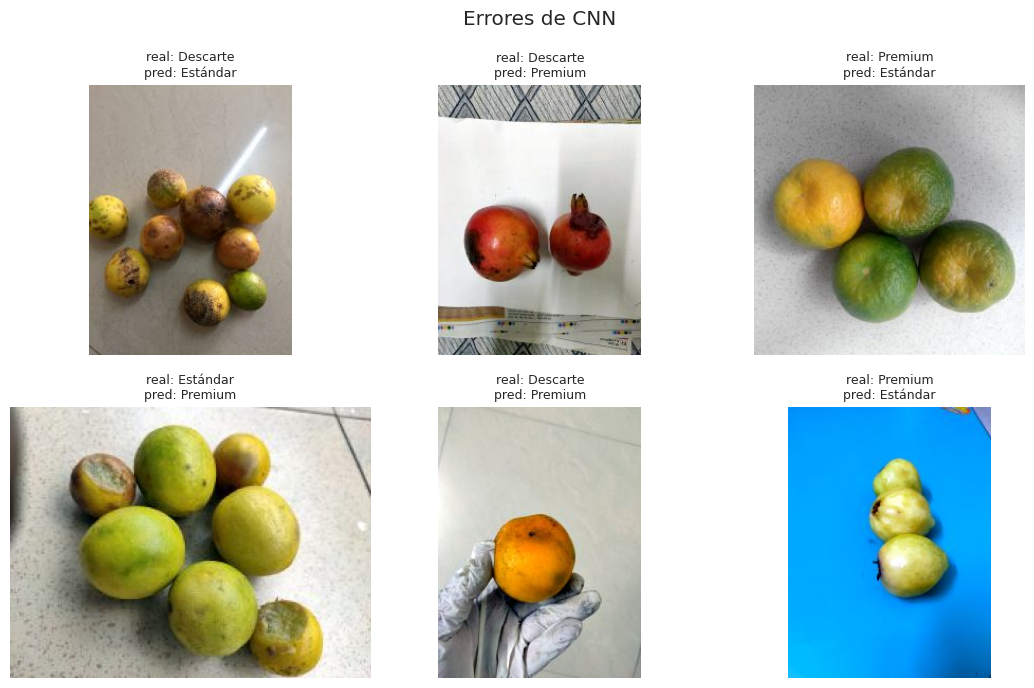

In [7]:
best_name = results.drop('Baseline')['f1_macro'].idxmax()
best_pred = preds[best_name]
wrong = np.where(best_pred != yte)[0]
print(f"Mejor modelo: {best_name} | errores: {len(wrong)}/{len(yte)}")

# Pares de confusión más frecuentes
import collections
conf_pairs = collections.Counter(
    (QUALITY_CLASSES[yte[i]], QUALITY_CLASSES[best_pred[i]]) for i in wrong)
print("\nConfusiones más frecuentes (real -> predicho):")
for (a,b), c in conf_pairs.most_common(5):
    print(f"  {a:9s} -> {b:9s}: {c}")

# Mostrar algunos ejemplos
sample = wrong[:6]
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, i in zip(axes.flatten(), sample):
    img = load_image_rgb(te_manifest.iloc[i]['abs_path'])
    ax.imshow(img); ax.axis('off')
    ax.set_title(f"real: {QUALITY_CLASSES[yte[i]]}\npred: {QUALITY_CLASSES[best_pred[i]]}", fontsize=9)
for ax in axes.flatten()[len(sample):]: ax.axis('off')
plt.suptitle(f"Errores de {best_name}")
plt.tight_layout(); plt.savefig(FIGURES_DIR / "fase5_errores.pdf", bbox_inches="tight")
plt.show()

## 6. Evaluación fuera de distribución (OOD) — imágenes propias
Esta sección evalúa los modelos **ya entrenados** sobre las imágenes recolectadas
por el grupo (`data/raw/` + `labels_own.csv`). Mide la **generalización real** a
otra cámara/iluminación/fondo. Si aún no hay imágenes propias, muestra el estado.

> **Cómo activarla:** ver el bloque siguiente. No reentrena nada: solo predice.

In [8]:
own_csv = PROCESSED_DIR / "manifest_own.csv"
if not own_csv.exists():
    print("⏳ Aún no hay manifest_own.csv.")
    print("   Pasos: 1) poner imágenes en data/raw/  2) anotar labels_own.csv")
    print("          3) ejecutar: from src.data.preprocessing import build_own_manifest; build_own_manifest()")
    print("   Luego re-ejecuta esta celda para ver la evaluación OOD.")
else:
    own = pd.read_csv(own_csv)
    own['abs_path'] = own['path']
    Xown, yown = build_feature_matrix(own.rename(columns={'path':'path'}), 'own', use_cache=False)
    Xown_img = load_imgs(own)
    ood = {
        'Random Forest': rf.predict(Xown),
        'XGBoost':       xgbm.predict(Xown),
        'CNN':           cnn.predict(Xown_img, verbose=0).argmax(1),
    }
    rows=[]
    for name,p in ood.items():
        rows.append({'modelo':name,'accuracy':accuracy_score(yown,p),
                     'f1_macro':f1_score(yown,p,average='macro')})
    print("=== Evaluación OOD (imágenes propias) ===")
    print(pd.DataFrame(rows).set_index('modelo').round(3))

⏳ Aún no hay manifest_own.csv.
   Pasos: 1) poner imágenes en data/raw/  2) anotar labels_own.csv
          3) ejecutar: from src.data.preprocessing import build_own_manifest; build_own_manifest()
   Luego re-ejecuta esta celda para ver la evaluación OOD.


## 7. Resumen de la Fase 5
- Tabla, matrices de confusión y **análisis de errores** documentados.
- **Bloque OOD** listo para las imágenes propias (test de generalización real).
- La salida de **tamaño** se evalúa por separado (medición por
  segmentación), no es una predicción de estos modelos.